# 🏠 Singapore HDB Resale Price Analysis & Prediction
## Notebook 3 — Feature Engineering

EDA (Notebook 2) told us *what matters*: time, location, size, floor, lease. This notebook turns those
findings into a model-ready feature matrix. All logic lives in the package
([`sg_hdb_price_analysis/features/engineering.py`](../sg_hdb_price_analysis/features/engineering.py)) so the
**dashboard uses the exact same code at inference time** — no train/serve skew.

### The geospatial pipeline (run once, cached)

The raw data has no coordinates, only `block` + `street_name`. Two free APIs fix that:

| Step | Script | Source | Output |
|------|--------|--------|--------|
| Geocode 9.7k unique addresses | `data/geocode.py` | OneMap (SG gov geocoder) | `data/external/address_coords.csv` (96% matched) |
| MRT/LRT stations (164) + bus stops (5.9k) | `data/transit.py` | OpenStreetMap Overpass | `data/external/{mrt_stations,bus_stops}.csv` |
| Nearest-distance features | `features/spatial.py` | scikit-learn **BallTree** (haversine metric) | merged into the feature matrix |

A BallTree query is O(log n) per lookup — computing nearest-MRT for 232k transactions takes seconds.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook lives in notebooks/ — project root is one level up. The fallback lets
# the same code run whether the kernel starts in notebooks/ or the repo root.
ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
FIGURES = ROOT / "reports" / "figures"      # charts are saved here for the README/report
FIGURES.mkdir(parents=True, exist_ok=True)

# Consistent plot styling across the whole notebook.
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 5)
pd.set_option("display.max_columns", 40)

In [2]:
# build_features is the single source of truth for feature engineering — the
# dashboard and API import the very same function, so there's no train/serve skew.
from sg_hdb_price_analysis.features.engineering import (
    build_features, BASE_NUMERIC_FEATURES, COORD_FEATURES, CATEGORICAL_COLS, TARGET,
)

raw = pd.read_csv(ROOT / "data" / "raw" / "hdb_resale_prices_all.csv", parse_dates=["month"])
df = build_features(raw)          # ← the one function that builds every feature
print(f"{len(df):,} rows, {df.shape[1]} columns after feature engineering")

232,614 rows, 28 columns after feature engineering


## 1. The engineered features, one by one

| Feature | How it's built | Why (EDA evidence) |
|---------|----------------|--------------------|
| `time_index` | months since 2017-01 | captures the +60% market trend as one smooth number |
| `storey_mid` | midpoint of `storey_range` band | monotonic storey premium |
| `remaining_lease_exact` | parse `"61 years 04 months"` → 61.33 | lease decay curve |
| `flat_age` | sale year − lease commence year | building age ≠ lease (captures estate quality) |
| `flat_type_ord` | 1 ROOM=1 … MULTI-GEN=7 | flat types are ordered |
| `lat`, `lon` | OneMap geocoding | lets the model learn micro-location |
| `dist_cbd_m` | haversine distance to Raffles Place | 50%+ town price gap is largely centrality |
| `dist_nearest_mrt_m` | BallTree nearest MRT/LRT | transit premium |
| `dist_nearest_bus_m`, `n_bus_400m` | BallTree on 5.9k bus stops | local connectivity |
| `town`, `flat_model` | kept as categoricals | residual within-town effects |

In [3]:
# Inspect a few rows of the engineered columns next to their raw inputs.
example_cols = ["month", "town", "flat_type", "storey_range", "remaining_lease",
                "time_index", "storey_mid", "remaining_lease_exact", "flat_age",
                "lat", "lon", "dist_cbd_m", "dist_nearest_mrt_m"]
df[example_cols].head(5)

,month,town,flat_type,storey_range,remaining_lease,time_index,storey_mid,remaining_lease_exact,flat_age,lat,lon,dist_cbd_m,dist_nearest_mrt_m
0,2017-01-01,ANG MO KIO,2 ROOM,10 TO 12,61 years 04 months,1,11,61.333333,38,1.362005,103.853880,8789.584168,1020.279537
1,2017-01-01,SEMBAWANG,4 ROOM,01 TO 03,82 years 06 months,1,2,82.500000,17,1.452085,103.816554,19193.992957,512.004701
2,2017-01-01,QUEENSTOWN,5 ROOM,19 TO 21,88 years 11 months,1,20,88.916667,11,1.293313,103.808253,4920.838826,286.238337
3,2017-01-01,QUEENSTOWN,5 ROOM,19 TO 21,85 years 08 months,1,20,85.666667,14,1.308083,103.783057,8082.791509,617.735191
4,2017-01-01,QUEENSTOWN,5 ROOM,04 TO 06,57 years,1,5,57.000000,42,1.310976,103.792380,7251.120540,489.500664


In [4]:
# How many transactions got coordinates? The ~4% that OneMap couldn't geocode
# keep NaN spatial features and are median-imputed at training time.
geocoded = df["lat"].notna().sum()
print(f"Geocoding coverage: {geocoded:,} / {len(df):,} transactions ({geocoded/len(df):.1%})")
print("→ remaining NaNs are median-imputed at training time (see Notebook 4)")

Geocoding coverage: 223,409 / 232,614 transactions (96.0%)
→ remaining NaNs are median-imputed at training time (see Notebook 4)


## 2. Validating the spatial features

If the geospatial work was worth it, distance-to-CBD and distance-to-MRT should show clear
price gradients. We check on price-per-sqm (controls for unit size).

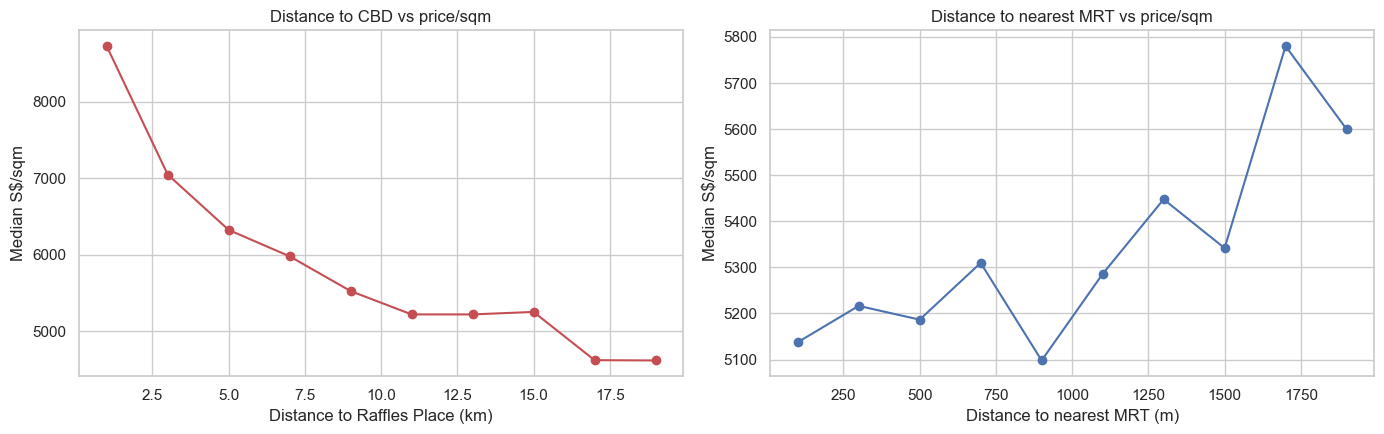

In [5]:
# Validate the spatial features: if geocoding was worth it, price/sqm should fall
# steadily with distance to the CBD and to the nearest MRT. Bin then take medians.
geo = df.dropna(subset=["lat"]).copy()
geo["cbd_km_bin"] = pd.cut(geo["dist_cbd_m"] / 1000, bins=range(0, 22, 2))
geo["mrt_m_bin"] = pd.cut(geo["dist_nearest_mrt_m"], bins=range(0, 2200, 200))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
cbd_curve = geo.groupby("cbd_km_bin", observed=True)["price_per_sqm"].median()
axes[0].plot([b.mid for b in cbd_curve.index], cbd_curve.values, "o-", color="#C44E52")
axes[0].set(title="Distance to CBD vs price/sqm", xlabel="Distance to Raffles Place (km)", ylabel="Median S$/sqm")

mrt_curve = geo.groupby("mrt_m_bin", observed=True)["price_per_sqm"].median()
axes[1].plot([b.mid for b in mrt_curve.index], mrt_curve.values, "o-", color="#4C72B0")
axes[1].set(title="Distance to nearest MRT vs price/sqm", xlabel="Distance to nearest MRT (m)", ylabel="Median S$/sqm")
plt.tight_layout()
plt.savefig(FIGURES / "spatial_gradients.png", dpi=150, bbox_inches="tight")

Both gradients are strong and monotonic: **every km away from the CBD costs ~S$100/sqm**, and prices fall
steadily as MRT distance grows past ~400m. These two engineered features alone encode most of what
"good location" means in Singapore.

## 3. A map sanity-check

Plotting price per sqm on actual coordinates — the hot core around the city centre should glow.

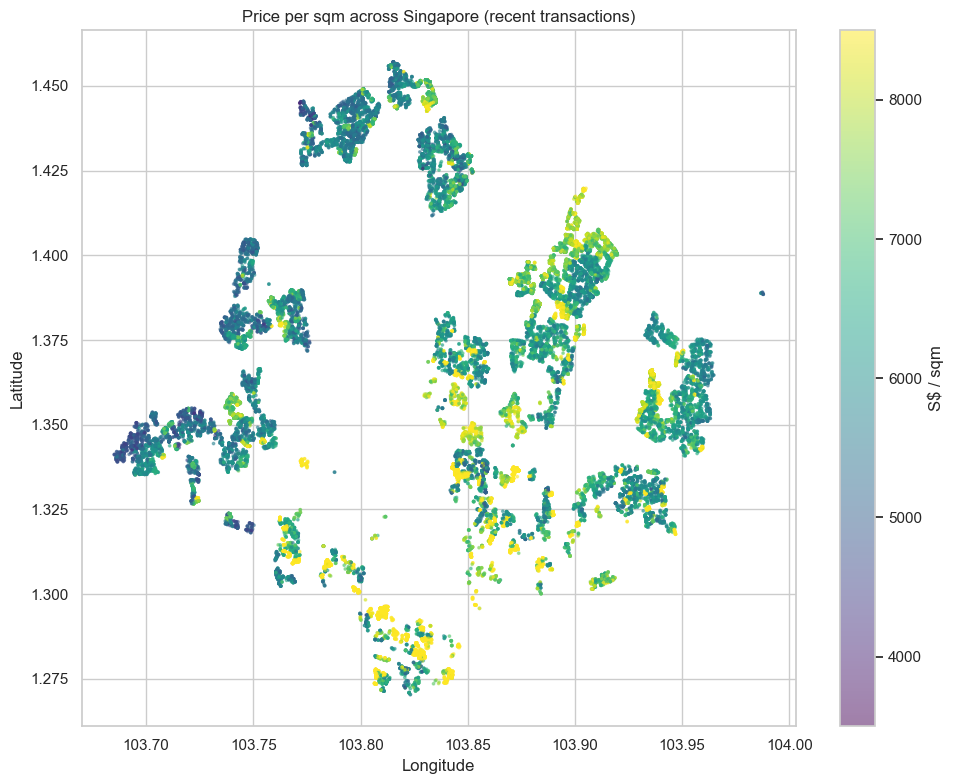

In [6]:
# Map check: plot price/sqm on real coordinates — the central core should glow.
recent_geo = geo[geo["year"] >= geo["year"].max() - 1]
fig, ax = plt.subplots(figsize=(10, 8))
sc = ax.scatter(recent_geo["lon"], recent_geo["lat"], c=recent_geo["price_per_sqm"],
                s=3, cmap="viridis", vmin=3500, vmax=8500, alpha=0.5)
ax.set(title="Price per sqm across Singapore (recent transactions)", xlabel="Longitude", ylabel="Latitude")
plt.colorbar(sc, label="S$ / sqm")
plt.tight_layout()
plt.savefig(FIGURES / "price_map.png", dpi=150, bbox_inches="tight")

## 4. Feature ↔ target correlations

,corr_with_price
flat_age,-0.301
dist_cbd_m,-0.218
lat,-0.169
n_bus_400m,0.006
dist_nearest_bus_m,0.037
dist_nearest_mrt_m,0.087
lon,0.095
remaining_lease_exact,0.302
storey_mid,0.342
time_index,0.408


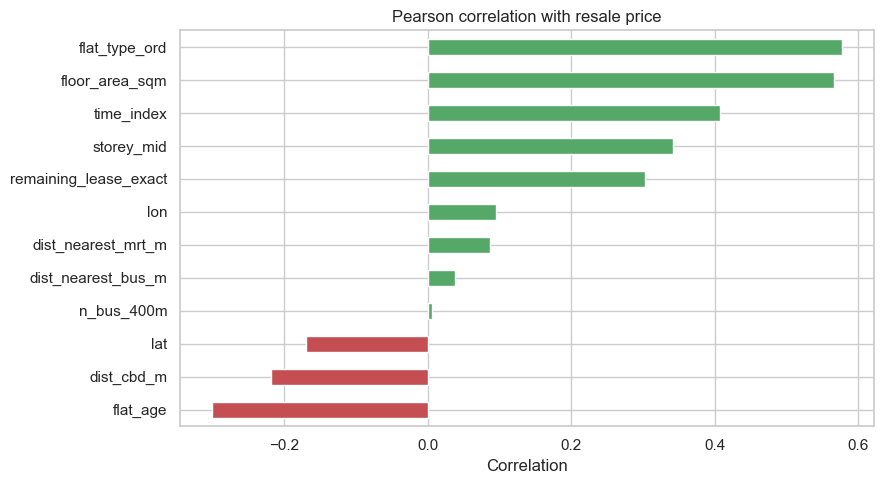

In [7]:
# Pearson correlation of each feature with price. lat/lon look weak here because
# their effect is non-linear (spatial) — trees will still exploit them heavily.
feat_corr = (
    df[BASE_NUMERIC_FEATURES + [c for c in COORD_FEATURES if c in df.columns] + [TARGET]]
    .corr()[TARGET].drop(TARGET).sort_values()
)
fig, ax = plt.subplots(figsize=(9, 5))
feat_corr.plot.barh(color=np.where(feat_corr > 0, "#55A868", "#C44E52"), ax=ax)
ax.set(title="Pearson correlation with resale price", xlabel="Correlation")
plt.tight_layout()
feat_corr.round(3).to_frame("corr_with_price")

Linear correlations understate non-linear effects (lat/lon mean nothing linearly but are gold for trees),
which is one more argument for gradient-boosted trees over linear models.

### Features deliberately dropped
Tested in the experiment harness (`models/experiment.py`) and removed for ~zero importance:
raw `flat_type`/`storey_range` categoricals (redundant with their ordinal versions), `n_mrt_1km`
(redundant with MRT distance), and an `is_mature` estate flag (absorbed by `town`).

## 5. Cache the feature matrix

In [8]:
# Cache the engineered matrix to parquet so Notebooks 4 & 5 load instantly
# instead of re-running the (slower) spatial joins.
out = ROOT / "data" / "interim" / "features_full.parquet"
df.to_parquet(out, index=False)
print(f"Saved {len(df):,} rows × {df.shape[1]} cols → {out.relative_to(ROOT)}")

FINAL_FEATURES = BASE_NUMERIC_FEATURES + [c for c in COORD_FEATURES if c in df.columns] + CATEGORICAL_COLS
print(f"\nFinal model feature set ({len(FINAL_FEATURES)}): {FINAL_FEATURES}")

Saved 232,614 rows × 28 cols → data/interim/features_full.parquet

Final model feature set (14): ['floor_area_sqm', 'storey_mid', 'remaining_lease_exact', 'flat_type_ord', 'time_index', 'flat_age', 'lat', 'lon', 'dist_cbd_m', 'dist_nearest_mrt_m', 'dist_nearest_bus_m', 'n_bus_400m', 'town', 'flat_model']


**Next →** [Notebook 4: Model Building & Hyperparameter Tuning](04_model_building_and_tuning.ipynb)